In [54]:
import psycopg2
from sqlalchemy import create_engine, Column, Integer, String
from sqlalchemy.ext.declarative import declarative_base
from sqlalchemy.orm import sessionmaker
import pandas as pd
import missingno as msno
import numpy as np
from parameters import db_params
import matplotlib.pyplot as plt
import seaborn as sns

# Create a connection string
conn_string = f"postgresql+psycopg2://{db_params['user']}:{db_params['password']}@{db_params['host']}:{db_params['port']}/{db_params['database']}"

# Create an SQLAlchemy engine
engine = create_engine(conn_string)

# Use pandas to execute a query and load data into a DataFrame
query = "SELECT * FROM data_lake.safe_driving"
df_safe_driving = pd.read_sql(query, engine)

# Close the connection
engine.dispose()

In [55]:
df_safe_driving.head(5)

,eventid,event_start,event_end,duration_seconds,latitude,longitude,speed_kmh,end_speed_kmh,maxwaarde,category,incident_severity,is_valid,road_segment_id,road_manager_type,road_number,road_name,place_name,municipality_name,road_manager_name
0,27421010,2019-05-08 04:55:29.400,2019-05-08 04:55:30.500,1.1,51.60173,4.790177,32.186880,40.233600,0.828812,HARSH CORNERING,HC1,True,227203128,G,,Nieuwe Kadijk,Breda,Breda,Breda
1,27437991,2019-05-08 06:39:16.500,2019-05-08 06:39:17.900,1.4,51.59288,4.829847,37.014910,37.014910,0.729033,HARSH CORNERING,HC1,True,600122997,G,,Tilburgseweg,Breda,Breda,Breda
2,27465558,2019-05-08 22:02:21.300,2019-05-08 22:02:22.400,1.1,51.59364,4.804021,28.968191,25.749504,0.804672,HARSH CORNERING,HC1,True,600941103,G,,Teteringsedijk,Breda,Breda,Breda
3,27423842,2019-05-08 05:24:11.700,2019-05-08 05:24:15.000,3.3,51.61324,4.753860,19.312128,32.186880,0.878702,ACCELERATING,HA1,True,600750701,G,,Emerparklaan,Breda,Breda,Breda
4,27498183,2019-05-08 15:25:13.000,2019-05-08 15:25:24.000,11.0,51.57193,4.763523,62.764416,62.764416,64.373760,SPEED,SP1,True,600751226,G,,Graaf Engelbertlaan,Breda,Breda,Breda


In [56]:
df = df_safe_driving

# Checking for duplicate values
dup_count = df.duplicated().sum()
print('There are', dup_count, 'duplicate values')

# Counting the missing values
missing_count = df.isnull().sum().sum()
print('There are', missing_count, 'missing values')

print(df.isnull().sum().sort_values(ascending=False))

There are 0 duplicate values
There are 0 missing values
eventid              0
incident_severity    0
municipality_name    0
place_name           0
road_name            0
road_number          0
road_manager_type    0
road_segment_id      0
is_valid             0
category             0
event_start          0
maxwaarde            0
end_speed_kmh        0
speed_kmh            0
longitude            0
latitude             0
duration_seconds     0
event_end            0
road_manager_name    0
dtype: int64


There are a total of 0 missing values


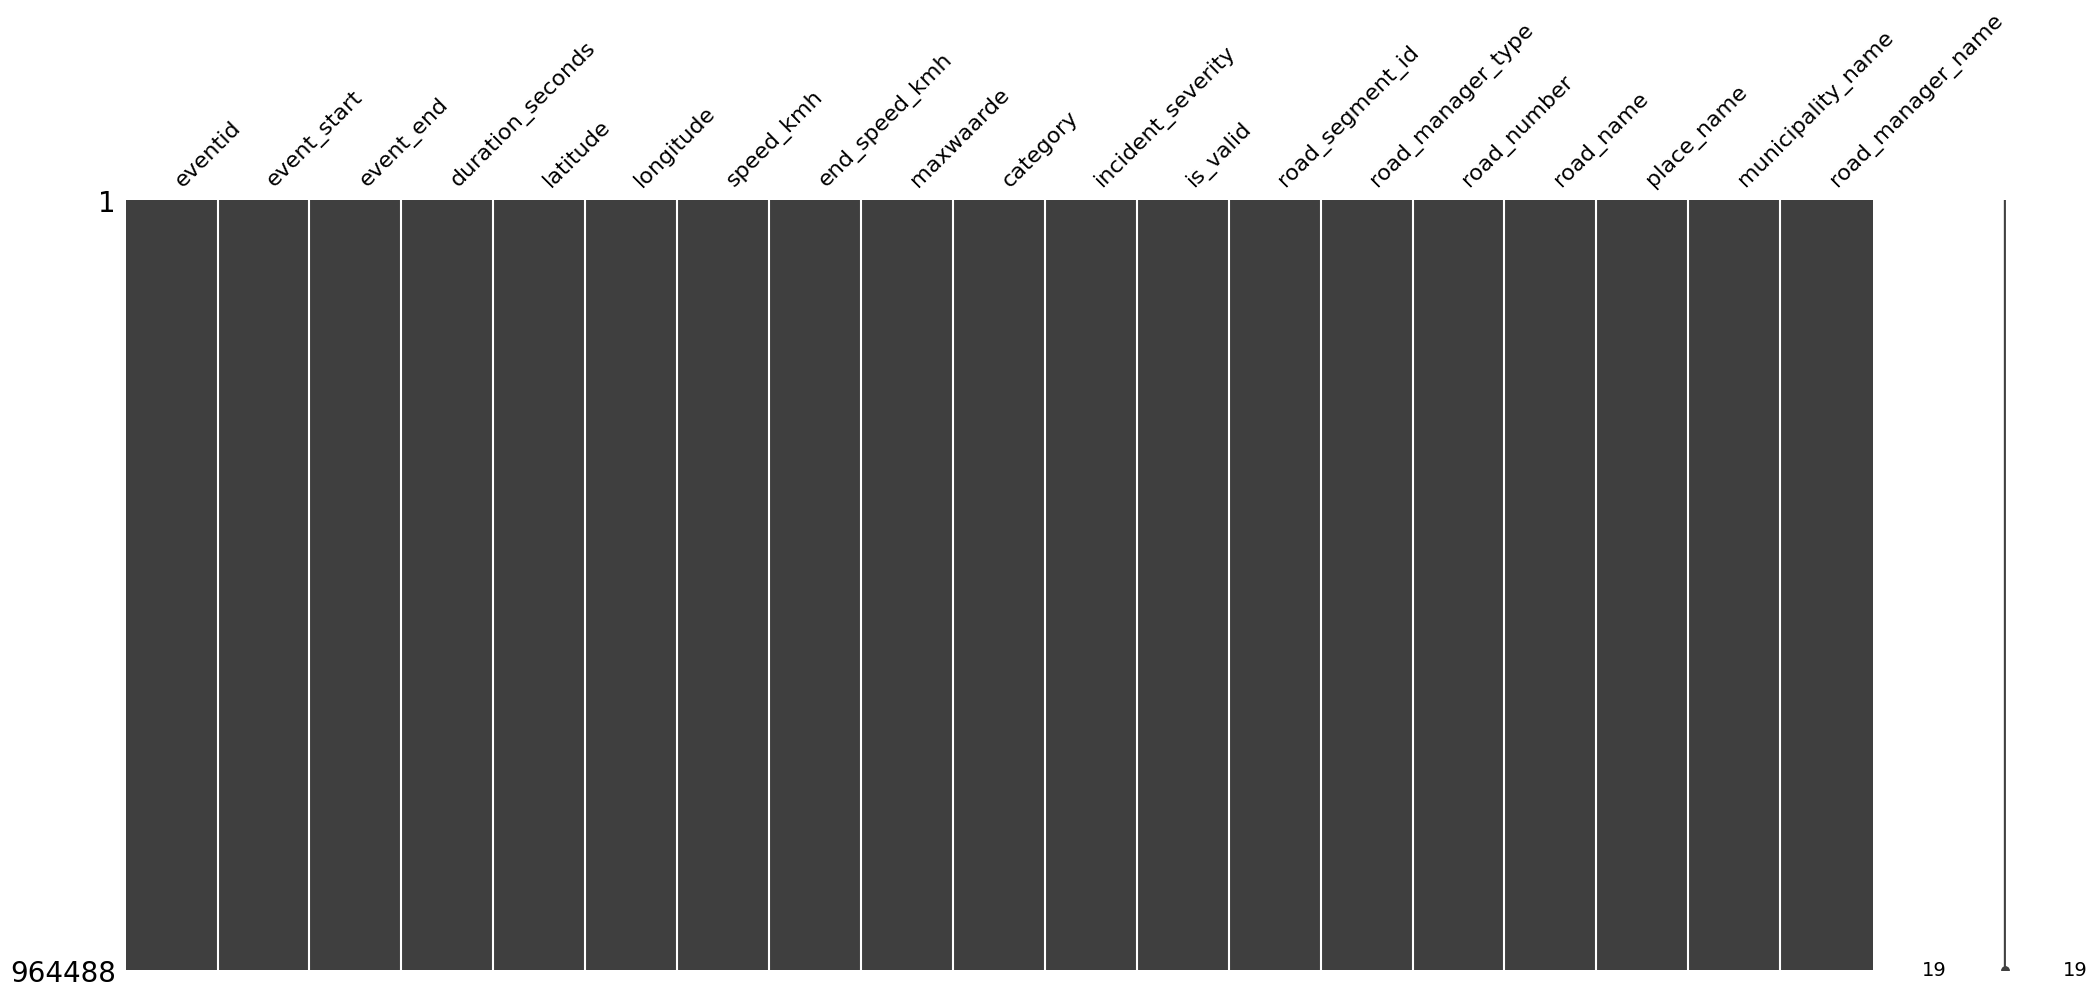

In [57]:
# Print a map of all the missing values, they are white
msno.matrix(df)
missing_counts = df.isnull().sum().sum()
print(f'There are a total of {missing_counts} missing values')

In [58]:
# Ensure 'event_start' and 'event_end' are in datetime format
df_safe_driving['event_start'] = pd.to_datetime(df_safe_driving['event_start'])
df_safe_driving['event_end'] = pd.to_datetime(df_safe_driving['event_end'])

# Check for duplicate values
dup_count = df_safe_driving.duplicated().sum()
print('There are', dup_count, 'duplicate values')

# Re-check for missing values in different forms
missing_count = df_safe_driving.isnull().sum().sum()
print('There are', missing_count, 'missing values')

# Set the future option to opt-in to the new behavior
pd.set_option('future.no_silent_downcasting', True)

# Replace empty strings with NaN in the 'road_number' column
df_safe_driving['road_number'] = df_safe_driving['road_number'].replace("", np.nan)

# Verify that the replacement has been done
missing_values_count = df_safe_driving.isnull().sum()
print("Total missing values per column:")
print(missing_values_count[missing_values_count > 0])

# Summarize findings
total_missing = missing_values_count.sum()
print(f"Total number of missing values (including special values): {total_missing}")


There are 0 duplicate values
There are 0 missing values
Total missing values per column:
road_number    964488
dtype: int64
Total number of missing values (including special values): 964488


In [59]:
df = df_safe_driving

# Checking for duplicate values
dup_count = df.duplicated().sum()
print('There are', dup_count, 'duplicate values')

# Counting the missing values
missing_count = df.isnull().sum().sum()
print('There are', missing_count, 'missing values')

print(df.isnull().sum().sort_values(ascending=False))

There are 0 duplicate values
There are 964488 missing values
road_number          964488
eventid                   0
incident_severity         0
municipality_name         0
place_name                0
road_name                 0
road_manager_type         0
road_segment_id           0
is_valid                  0
category                  0
event_start               0
maxwaarde                 0
end_speed_kmh             0
speed_kmh                 0
longitude                 0
latitude                  0
duration_seconds          0
event_end                 0
road_manager_name         0
dtype: int64


In [60]:
total_rows = df_safe_driving.shape[0]
print("Total number of rows:", total_rows)


Total number of rows: 964488


In [61]:
# Remove the 'road_number' column
df_safe_driving = df_safe_driving.drop('road_number', axis=1)

# Verify that the rows with missing 'road_number' values have been removed
print(df_safe_driving.isna().sum())

eventid              0
event_start          0
event_end            0
duration_seconds     0
latitude             0
longitude            0
speed_kmh            0
end_speed_kmh        0
maxwaarde            0
category             0
incident_severity    0
is_valid             0
road_segment_id      0
road_manager_type    0
road_name            0
place_name           0
municipality_name    0
road_manager_name    0
dtype: int64


In [62]:
print(df_safe_driving['category'].unique())

['HARSH CORNERING ' 'ACCELERATING    ' 'SPEED           '
 'BRAKING         ' 'SPEED' 'HARSH CORNERING' 'ACCELERATING' 'BRAKING']


In [63]:
# Strip whitespace from the 'category' column
df_safe_driving['category'] = df_safe_driving['category'].str.strip()

# Print the unique values
print(df_safe_driving['category'].unique())


['HARSH CORNERING' 'ACCELERATING' 'SPEED' 'BRAKING']


Number of outliers in 'speed_kmh': 1844
Number of outliers in 'end_speed_kmh': 1656
Number of outliers in 'duration_seconds': 51933
Number of outliers in 'maxwaarde': 192


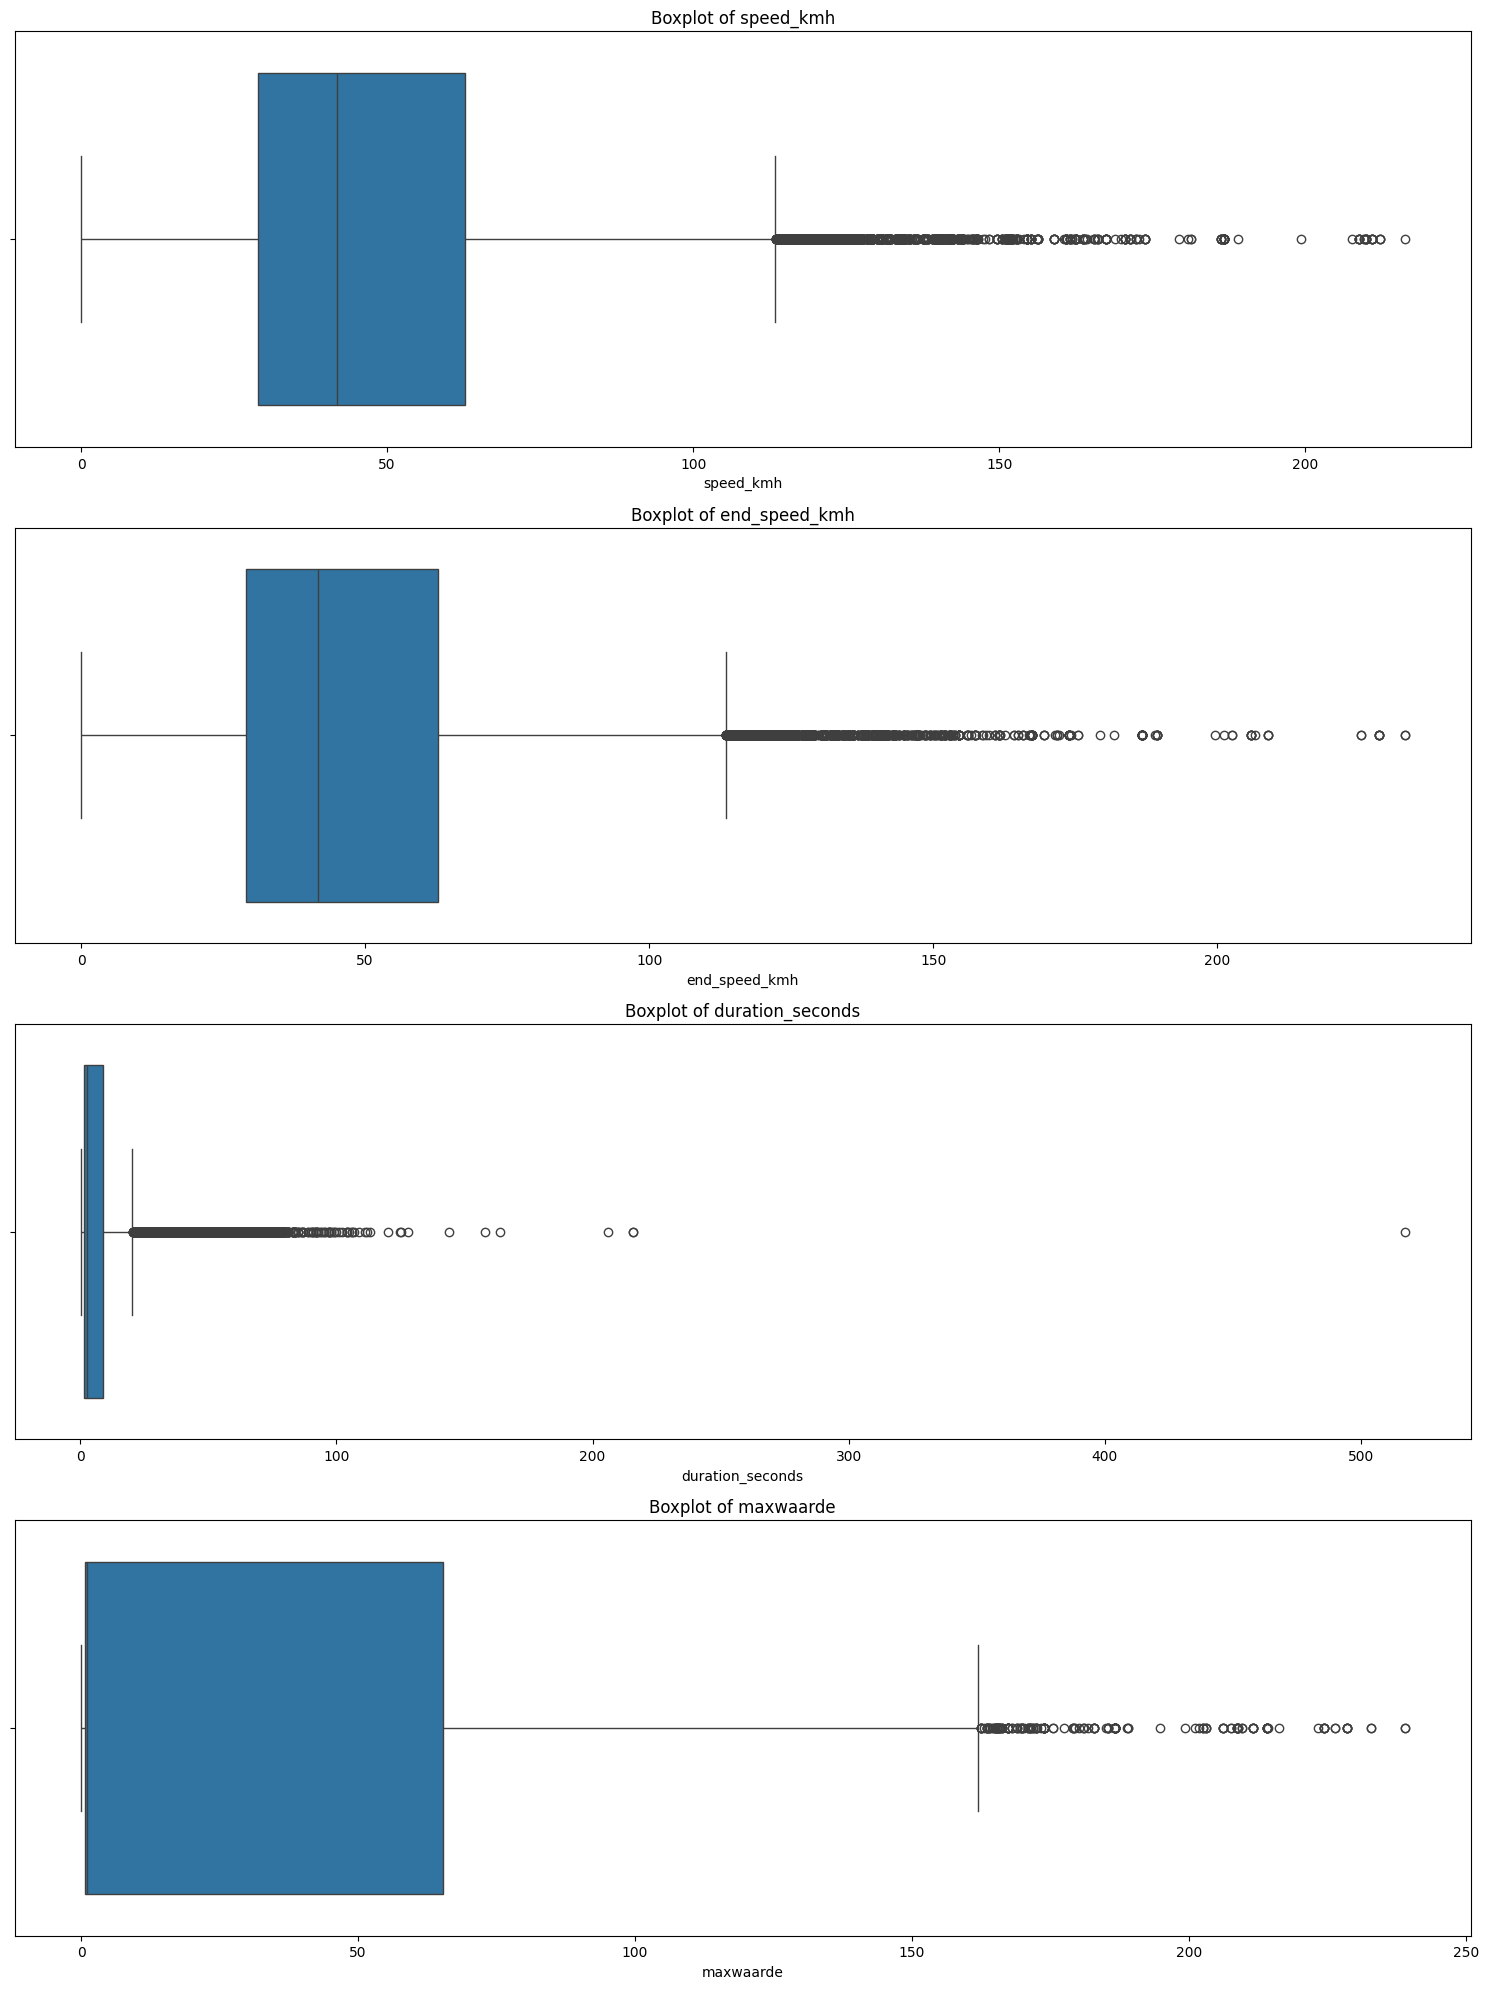

In [78]:
# Function to detect outliers using IQR
def detect_outliers_iqr(df, columns):
    outlier_summary = {}
    for column in columns:
        if pd.api.types.is_numeric_dtype(df[column]):
            Q1 = df[column].quantile(0.25)
            Q3 = df[column].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
            outlier_summary[column] = outliers.shape[0]
        else:
            outlier_summary[column] = 'Non-numeric data'
    return outlier_summary

# Function to plot boxplots for multiple columns
def plot_boxplots(df, columns):
    numeric_columns = [column for column in columns if pd.api.types.is_numeric_dtype(df[column])]
    plt.figure(figsize=(15, 5 * len(numeric_columns)))
    for i, column in enumerate(numeric_columns, 1):
        plt.subplot(len(numeric_columns), 1, i)
        sns.boxplot(x=df[column].dropna())
        plt.title(f'Boxplot of {column}')
    plt.tight_layout()
    plt.show()

# List of columns to check for outliers
columns_to_check = ['speed_kmh', 'end_speed_kmh', 'duration_seconds', 'maxwaarde']

# Detect outliers in the specified columns of df_wind
outlier_counts_wind = detect_outliers_iqr(df_safe_driving, columns_to_check)

# Print the summary of outliers for df_wind
for column, count in outlier_counts_wind.items():
    print(f"Number of outliers in '{column}': {count}")

# Plot boxplots for the specified columns in df_wind
plot_boxplots(df_safe_driving, columns_to_check)


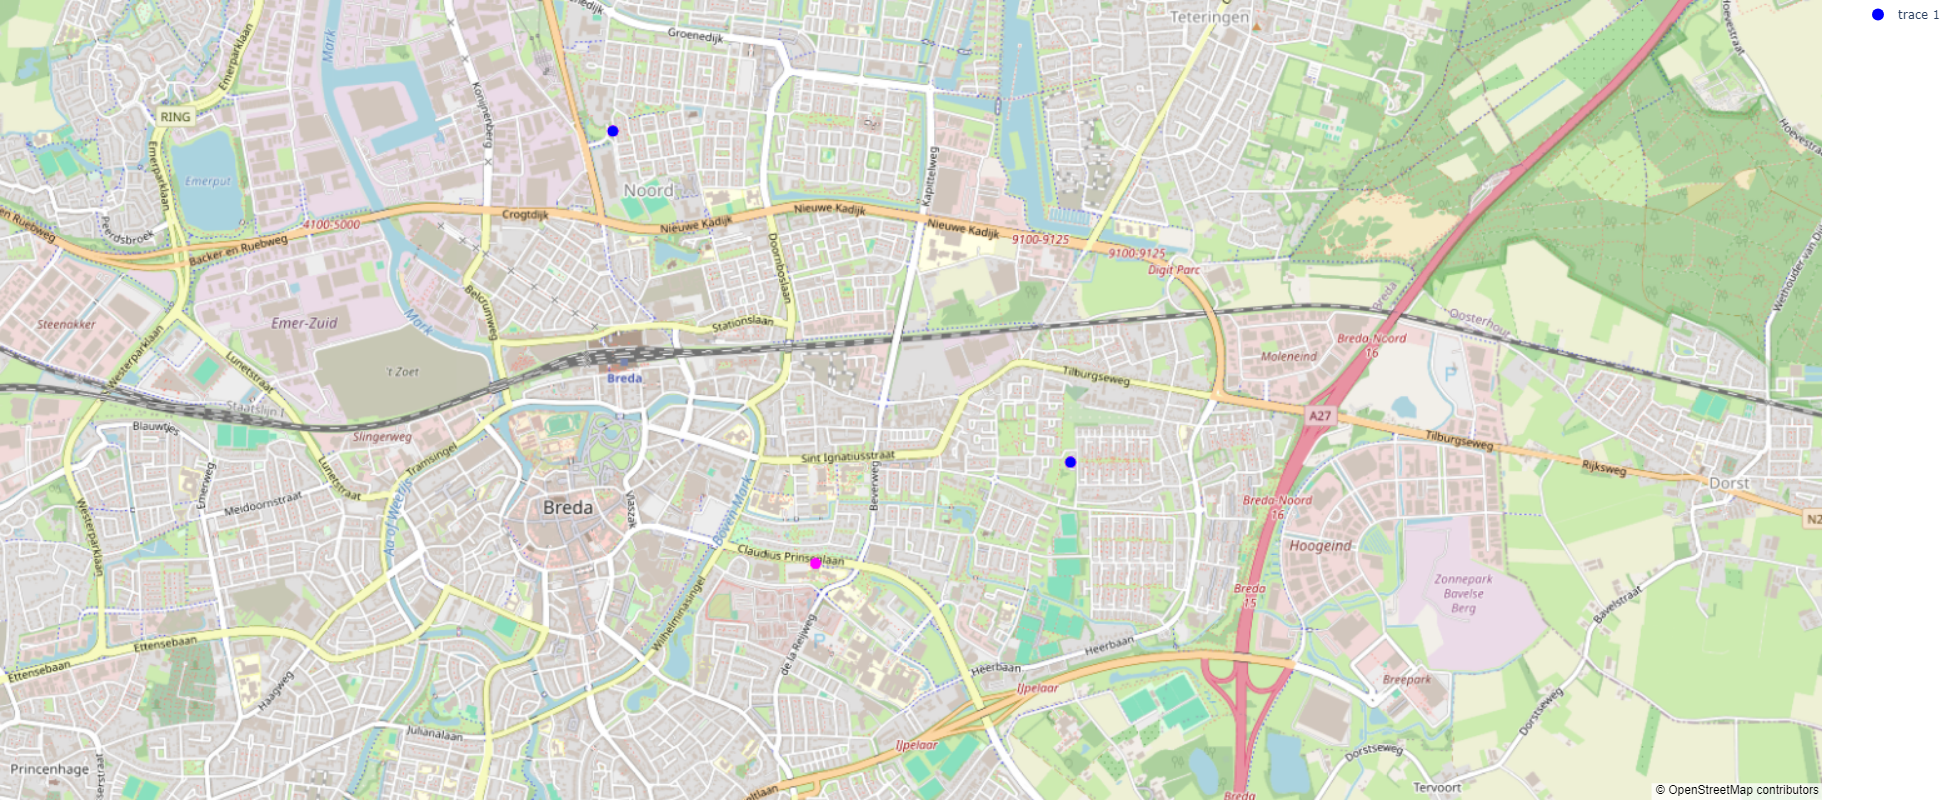

In [105]:
import plotly.express as px

# Filter the DataFrame
filtered_df = df_safe_driving[(df_safe_driving['category'] == 'SPEED') & (df_safe_driving['speed_kmh'] > 200)]

# Define the coordinates for the points to highlight
highlighted_points = pd.DataFrame({
    'latitude': [51.590760, 51.605330],
    'longitude': [4.811617, 4.779188],
    'category': ['SPEED', 'SPEED']
})

# Plot the filtered data
fig = px.scatter_mapbox(filtered_df,
                        lat='latitude',
                        lon='longitude',
                        color_discrete_sequence=["fuchsia"],
                        hover_name='category',
                        zoom=8,                        
                        height=800,
                        width=800)

# Customize the main markers to be larger and in fuchsia
fig.update_traces(marker=dict(size=12, color='fuchsia'))

# Add highlighted points with a different color
fig.add_scattermapbox(lat=highlighted_points['latitude'],
                      lon=highlighted_points['longitude'],
                      mode='markers',
                      marker=dict(size=12, color='blue'),  # Change the color here
                      hoverinfo='text',
                      hovertext=highlighted_points['category'])

fig.update_layout(mapbox_style="open-street-map") 
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

In [112]:
# Count the number of rows before removing outliers
rows_before = df_safe_driving.shape[0]

# Define the coordinates of the outliers
outlier_coords = [(51.605330, 4.779188), (51.590760, 4.811617)]

# Remove rows for outliers
for coord in outlier_coords:
    df_safe_driving = df_safe_driving[~((df_safe_driving['latitude'] == coord[0]) & (df_safe_driving['longitude'] == coord[1]))]

# Count the number of rows after removing outliers
rows_after = df_safe_driving.shape[0]

# Calculate the number of rows removed
rows_removed = rows_before - rows_after

# Print the number of rows removed
print("Number of rows removed:", rows_removed)


Number of rows removed: 10


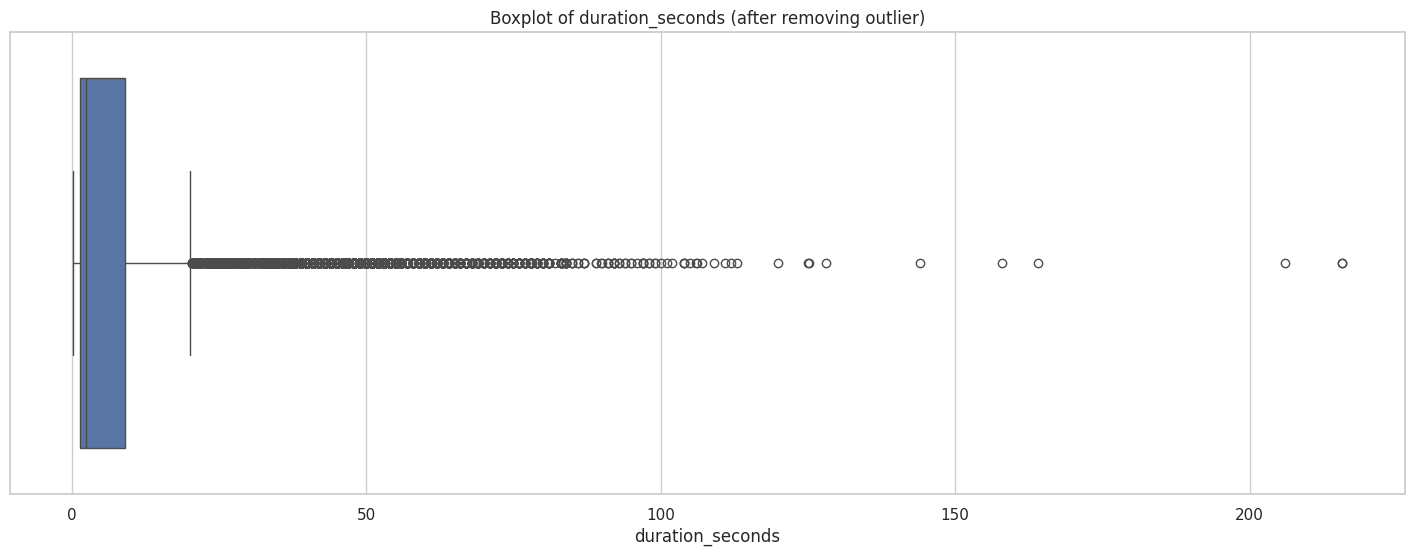

In [116]:
# Find the index of the outlier
outlier_index = df_safe_driving[df_safe_driving['duration_seconds'] > 500].index

# Drop the outlier row from the DataFrame
df_safe_driving = df_safe_driving.drop(outlier_index)

# Plot the boxplot of 'duration_seconds' again
plt.figure(figsize=(18, 6))
sns.boxplot(x=df_safe_driving['duration_seconds'].dropna())
plt.title('Boxplot of duration_seconds (after removing outlier)')
plt.show()


In [ ]:
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode the 'category' column
df_safe_driving['category_encoded'] = label_encoder.fit_transform(df_safe_driving['category'])


In [65]:
# Create a connection string
conn_string = f"postgresql+psycopg2://{db_params['user']}:{db_params['password']}@{db_params['host']}:{db_params['port']}/{db_params['database']}"

# Create an SQLAlchemy engine
engine = create_engine(conn_string)

# Use pandas to execute a query and load data into a DataFrame
query = "SELECT * FROM data_lake.wind"
df_wind = pd.read_sql(query, engine)

# Close the connection
engine.dispose()

In [66]:
df_wind.head()

,dtg,LOCATION,NAME,latitude,longitude,altitude,ff_10m_10,dd_10,ddn_10,dd_std_10,ddx_10,ff_sensor_10,ff_10m_std_10,fx_10m_10,fx_10m_md_10,fx_sensor_10,fx_sensor_md_10,squall_10
0,2017-12-03 16:20:00,350_W_a,Gilze-Rijen locatie A,51.565,4.935278,14.9,2.90,241.1,12.2,2.90,0.57,4.90,4.90,4.90,4.90,0.0,None,None
1,2017-12-03 16:30:00,350_W_a,Gilze-Rijen locatie A,51.565,4.935278,14.9,2.82,244.7,11.2,2.82,0.45,4.10,4.90,4.10,4.90,0.0,None,None
2,2017-12-03 16:40:00,350_W_a,Gilze-Rijen locatie A,51.565,4.935278,14.9,2.49,266.3,13.9,2.49,0.49,4.10,4.10,4.10,4.10,0.0,None,None
3,2017-12-03 16:50:00,350_W_a,Gilze-Rijen locatie A,51.565,4.935278,14.9,3.32,244.1,11.4,3.32,0.45,4.92,4.92,4.92,4.92,0.0,None,None
4,2017-12-03 17:00:00,350_W_a,Gilze-Rijen locatie A,51.565,4.935278,14.9,3.87,244.2,10.2,3.87,0.59,5.40,5.40,5.40,5.40,0.0,None,None


In [67]:
# Checking for duplicate values
dup_count = df_wind.duplicated().sum()
print('There are', dup_count, 'duplicate values')

# Counting the missing values
missing_count = df_wind.isnull().sum().sum()
print('There are', missing_count, 'missing values')

print(df_wind.isnull().sum().sort_values(ascending=False))

There are 0 duplicate values
There are 2352646 missing values
squall_10          1098837
fx_sensor_md_10    1098837
fx_sensor_10         15953
fx_10m_md_10         15897
fx_10m_10            15545
ff_10m_std_10        15421
ddx_10               15420
ff_sensor_10         15420
dd_std_10            15418
ddn_10               15351
dd_10                15291
ff_10m_10            15256
LOCATION                 0
altitude                 0
longitude                0
latitude                 0
NAME                     0
dtg                      0
dtype: int64


There are a total of 2352646 missing values


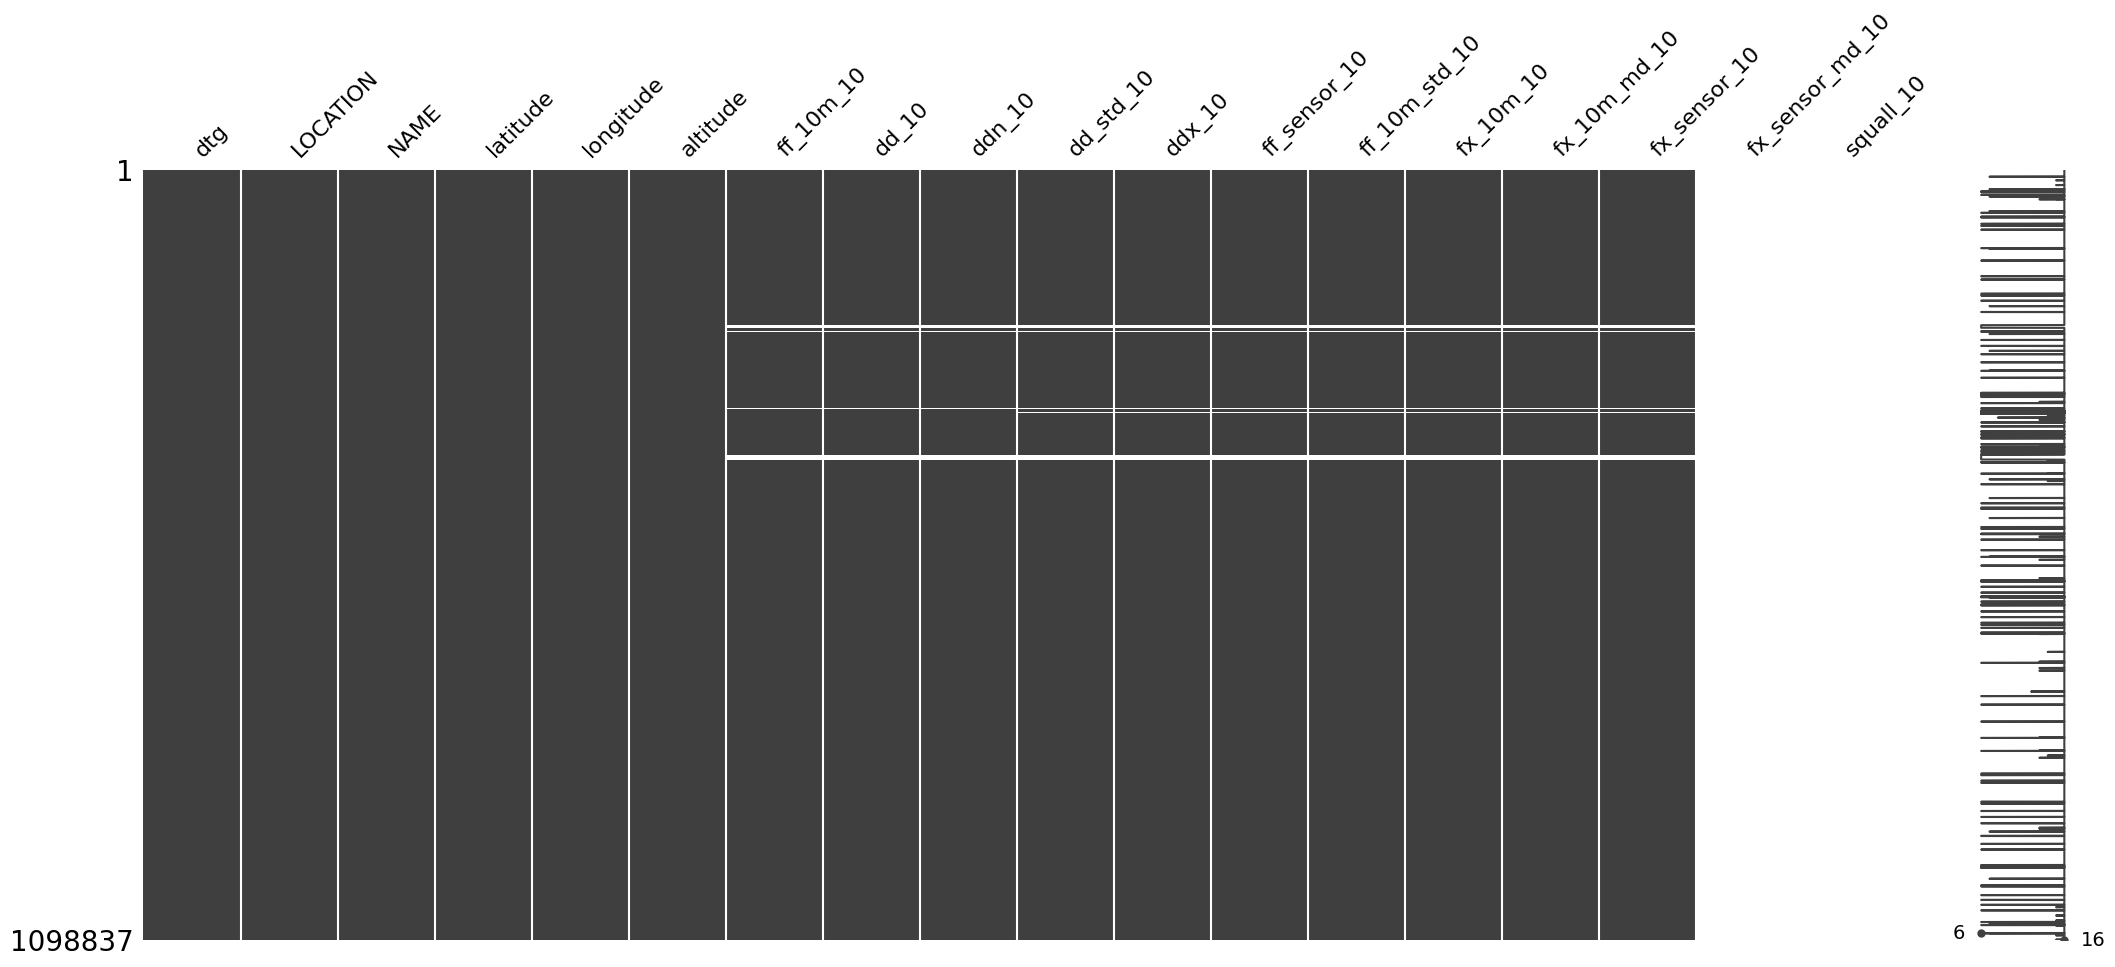

In [68]:
# Print a map of all the missing values, they are white
msno.matrix(df_wind)
missing_counts = df_wind.isnull().sum().sum()
print(f'There are a total of {missing_counts} missing values')

In [69]:
# Checking for duplicate values
dup_count = df_wind.duplicated().sum()
print('There are', dup_count, 'duplicate values')

# Counting the missing values
missing_count = df_wind.isnull().sum().sum()
print('There are', missing_count, 'missing values')

print(df_wind.isnull().sum().sort_values(ascending=False))

There are 0 duplicate values
There are 2352646 missing values
squall_10          1098837
fx_sensor_md_10    1098837
fx_sensor_10         15953
fx_10m_md_10         15897
fx_10m_10            15545
ff_10m_std_10        15421
ddx_10               15420
ff_sensor_10         15420
dd_std_10            15418
ddn_10               15351
dd_10                15291
ff_10m_10            15256
LOCATION                 0
altitude                 0
longitude                0
latitude                 0
NAME                     0
dtg                      0
dtype: int64


In [70]:
# Check for duplicate values
dup_count = df_wind.duplicated().sum()
print('There are', dup_count, 'duplicate values')

# Re-check for missing values in different forms
missing_count = df_wind.isnull().sum().sum()
print('There are', missing_count, 'missing values')

# Replace empty strings with NaN in all columns
df_wind.replace("", np.nan, inplace=True)

# Verify that the replacement has been done
missing_values_count = df_wind.isnull().sum()
print("Total missing values per column:")
print(missing_values_count[missing_values_count > 0])

# Summarize findings
total_missing = missing_values_count.sum()
print(f"Total number of missing values (including special values): {total_missing}")

There are 0 duplicate values
There are 2352646 missing values
Total missing values per column:
ff_10m_10            15256
dd_10                15291
ddn_10               15351
dd_std_10            15418
ddx_10               15420
ff_sensor_10         15420
ff_10m_std_10        15421
fx_10m_10            15545
fx_10m_md_10         15897
fx_sensor_10         15953
fx_sensor_md_10    1098837
squall_10          1098837
dtype: int64
Total number of missing values (including special values): 2352646


In [71]:
total_rows = df_wind.shape[0]
print("Total number of rows:", total_rows)


Total number of rows: 1098837


In [72]:
# Drop the columns
df_wind = df_wind.drop(columns=['fx_sensor_md_10', 'squall_10'])

In [73]:
# Check for duplicate values
dup_count = df_wind.duplicated().sum()
print('There are', dup_count, 'duplicate values')

# Re-check for missing values in different forms
missing_count = df_wind.isnull().sum().sum()
print('There are', missing_count, 'missing values')

# Replace empty strings with NaN in all columns
df_wind.replace("", np.nan, inplace=True)

# Verify that the replacement has been done
missing_values_count = df_wind.isnull().sum()
print("Total missing values per column:")
print(missing_values_count[missing_values_count > 0])

# Summarize findings
total_missing = missing_values_count.sum()
print(f"Total number of missing values (including special values): {total_missing}")

There are 0 duplicate values
There are 154972 missing values
Total missing values per column:
ff_10m_10        15256
dd_10            15291
ddn_10           15351
dd_std_10        15418
ddx_10           15420
ff_sensor_10     15420
ff_10m_std_10    15421
fx_10m_10        15545
fx_10m_md_10     15897
fx_sensor_10     15953
dtype: int64
Total number of missing values (including special values): 154972


In [74]:
# List of columns with missing values
columns_with_missing_values = ['ff_10m_10', 'dd_10', 'ddn_10', 'dd_std_10', 'ddx_10', 
                               'ff_sensor_10', 'ff_10m_std_10', 'fx_10m_10', 'fx_10m_md_10', 'fx_sensor_10']

# Fill missing values with the mean for each column
df_wind[columns_with_missing_values] = df_wind[columns_with_missing_values].fillna(df_wind[columns_with_missing_values].mean())

# Verify that missing values have been filled
missing_values_count = df_wind.isnull().sum()
print("Total missing values per column after imputation:")
print(missing_values_count[missing_values_count > 0])

Total missing values per column after imputation:
Series([], dtype: int64)


In [75]:
# Check for duplicate values
dup_count = df_wind.duplicated().sum()
print('There are', dup_count, 'duplicate values')

# Re-check for missing values in different forms
missing_count = df_wind.isnull().sum().sum()
print('There are', missing_count, 'missing values')

# Replace empty strings with NaN in all columns
df_wind.replace("", np.nan, inplace=True)

# Verify that the replacement has been done
missing_values_count = df_wind.isnull().sum()
print("Total missing values per column:")
print(missing_values_count[missing_values_count > 0])

# Summarize findings
total_missing = missing_values_count.sum()
print(f"Total number of missing values (including special values): {total_missing}")

There are 0 duplicate values
There are 0 missing values
Total missing values per column:
Series([], dtype: int64)
Total number of missing values (including special values): 0


Number of outliers in 'ff_10m_10': 18195
Number of outliers in 'dd_10': 0
Number of outliers in 'ddn_10': 232245
Number of outliers in 'dd_std_10': 73053
Number of outliers in 'ddx_10': 21450
Number of outliers in 'ff_sensor_10': 19006
Number of outliers in 'ff_10m_std_10': 18015
Number of outliers in 'fx_10m_10': 19000
Number of outliers in 'fx_10m_md_10': 19228
Number of outliers in 'fx_sensor_10': 15966


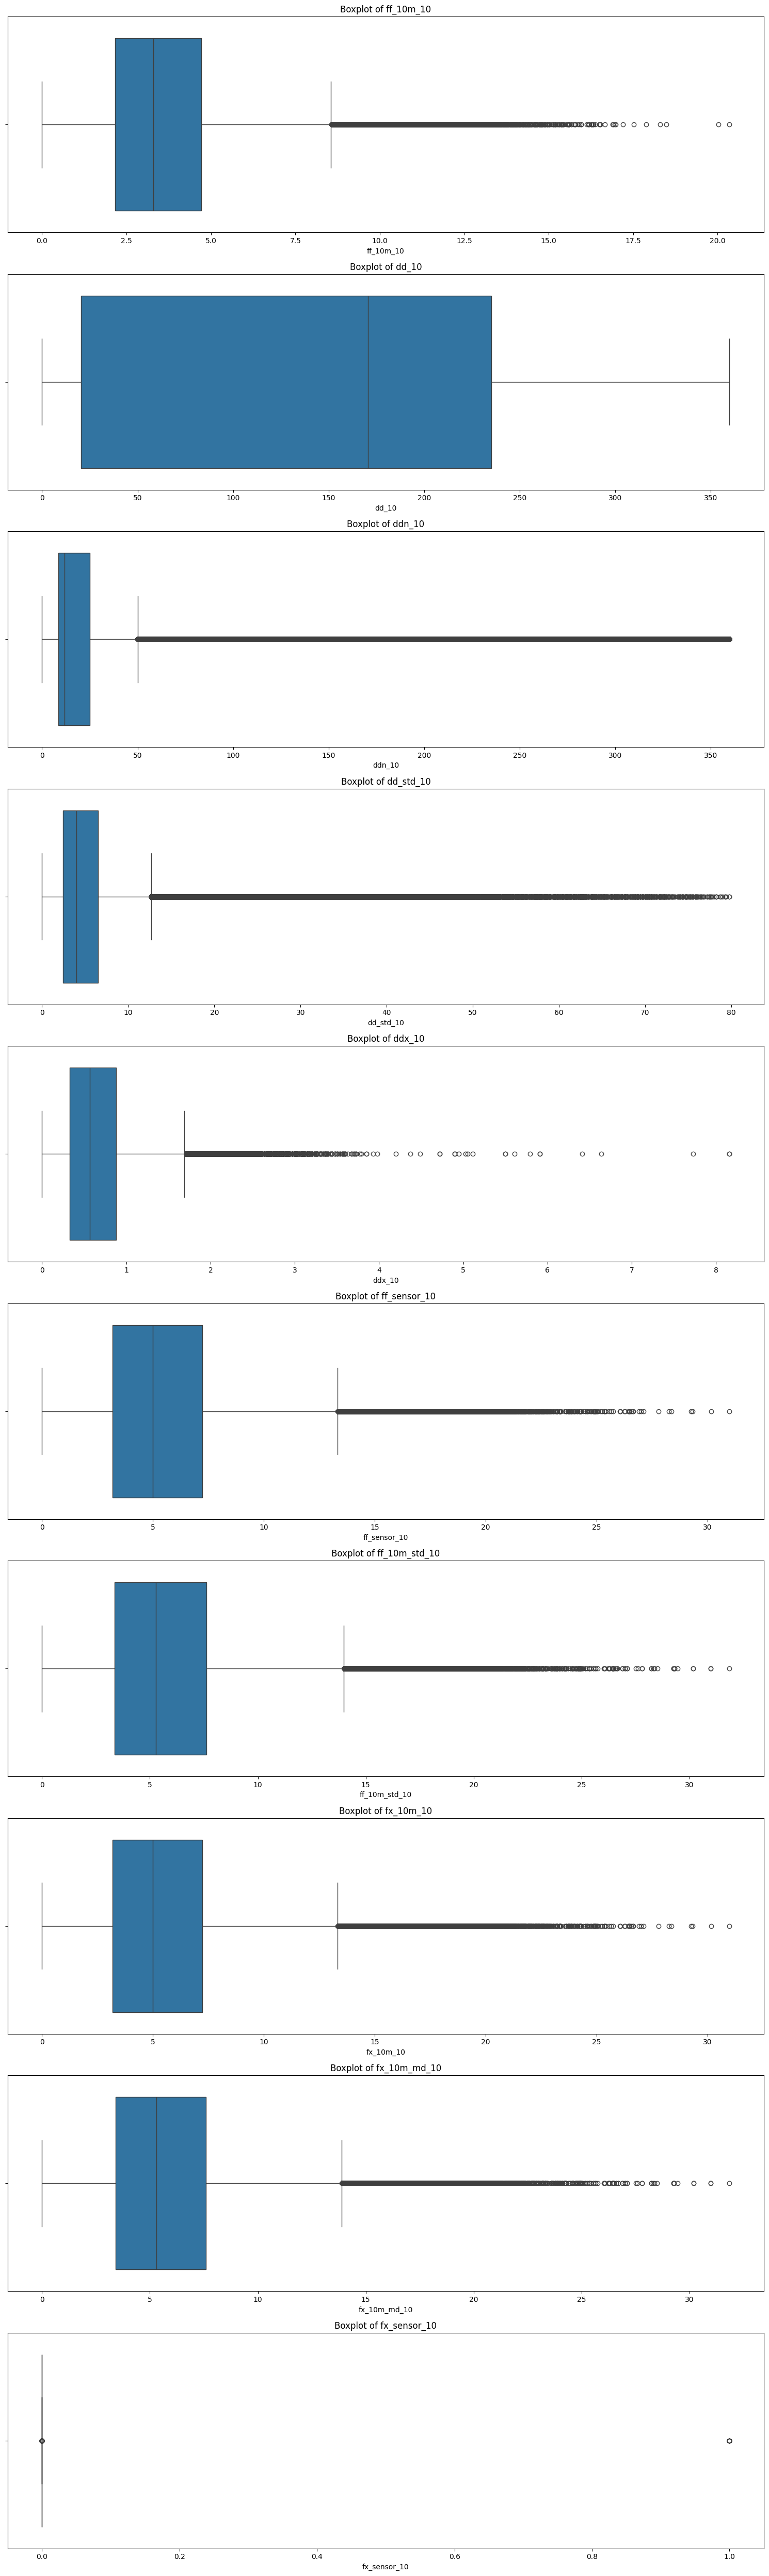

In [76]:
# Function to detect outliers using IQR
def detect_outliers_iqr(df, columns):
    outlier_summary = {}
    for column in columns:
        if pd.api.types.is_numeric_dtype(df[column]):
            Q1 = df[column].quantile(0.25)
            Q3 = df[column].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
            outlier_summary[column] = outliers.shape[0]
        else:
            outlier_summary[column] = 'Non-numeric data'
    return outlier_summary

# Function to plot boxplots for multiple columns
def plot_boxplots(df, columns):
    numeric_columns = [column for column in columns if pd.api.types.is_numeric_dtype(df[column])]
    plt.figure(figsize=(15, 5 * len(numeric_columns)))
    for i, column in enumerate(numeric_columns, 1):
        plt.subplot(len(numeric_columns), 1, i)
        sns.boxplot(x=df[column].dropna())
        plt.title(f'Boxplot of {column}')
    plt.tight_layout()
    plt.show()

# List of numerical columns to check for outliers in df_wind
columns_to_check_wind = [
    'ff_10m_10', 'dd_10', 'ddn_10', 'dd_std_10', 'ddx_10', 
    'ff_sensor_10', 'ff_10m_std_10', 'fx_10m_10', 'fx_10m_md_10', 
    'fx_sensor_10'
]

# Detect outliers in the specified columns of df_wind
outlier_counts_wind = detect_outliers_iqr(df_wind, columns_to_check_wind)

# Print the summary of outliers for df_wind
for column, count in outlier_counts_wind.items():
    print(f"Number of outliers in '{column}': {count}")

# Plot boxplots for the specified columns in df_wind
plot_boxplots(df_wind, columns_to_check_wind)


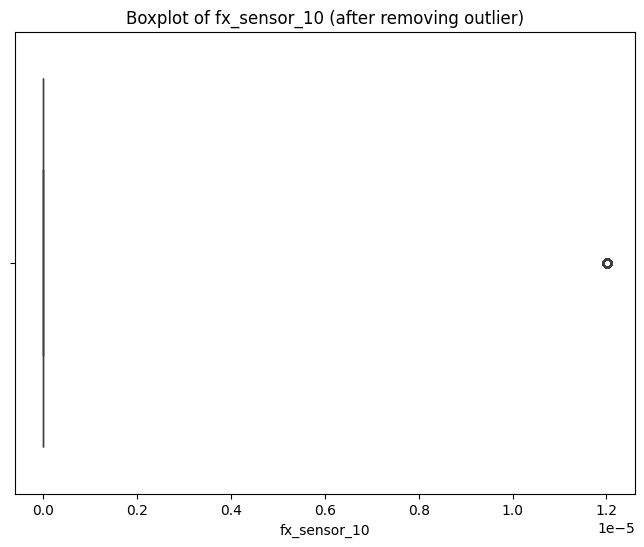

In [82]:
# Find the index of the outlier
outlier_index = df_wind[df_wind['fx_sensor_10'] > 0.8].index

# Drop the outlier row from the DataFrame
df_wind = df_wind.drop(outlier_index)

# Plot the boxplot of 'fx_sensor_10' again
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_wind['fx_sensor_10'].dropna())
plt.title('Boxplot of fx_sensor_10 (after removing outlier)')
plt.show()


In [88]:
# Print the count of each unique value in the 'fx_sensor_10' column
print(df_wind['fx_sensor_10'].value_counts())


fx_sensor_10
0.000000    1082871
0.000012      15953
Name: count, dtype: int64


So this column is not really important, since there are only 2 values